# MAL Omics — Proteomic Correlates of Mechanically Affected Lung
**Project:** COPDGene Multi-omics | **Analysis:** Proteomics Aim 2

## Goals
1. **Biological discovery:** identify peripheral plasma proteins associated with MAL (Mechanically Affected Lung)
2. **Biomarker development:** build a parsimonious proteomic risk score to enrich studies for MAL and emphysema progressors

## Analysis Roadmap
| Step | Analysis | Output |
|------|----------|--------|
| 1 | Demographics | Table 1 |
| 2 | Differential protein expression (protein ~ MAL) | Volcano plot, DE table |
| 3 | Gene set enrichment analysis (GSEA) | Pathway barplot |
| 4 | STRING protein–protein interaction network | Network figure |
| 5 | Adaptive LASSO → MAL proteomic risk score | Score weights table |
| 6 | Risk score ~ emphysema progression + AIC comparison | Quartile plot |
| 7 | Causal mediation: MAL → Risk Score → Progression | Table 2 |

## Section 0 — Background

**MAL (Mechanically Affected Lung):** CT-derived continuous score (0.01–0.40) quantifying
the proportion of lung volume undergoing destructive mechanical stress from pressure gradients.
Higher MAL = greater mechanical injury to alveolar tissue.

**Proteomics:** SomaScan 5K platform measures ~4,979 plasma proteins as RFU values (aptamer-based).
Log₂-transformed before analysis: 1-unit change = doubling of protein level.

**Emphysema progression:** `Change_lung_density_vnb_P2_P3` = Phase 3 − Phase 2 CT density (HU).
Negative = lung became less dense = emphysema worsened.

**Statistical rationale for adaptive lasso risk score:**
With n ≈ 1,300 subjects and p ≈ 4,979 proteins (p >> n), ordinary regression is
underdetermined. Adaptive lasso (Zou 2006) selects a parsimonious set of proteins
with oracle variable-selection consistency, then OLS refit yields unbiased effect estimates.

In [1]:
# =============================================================================
# SECTION 1: PACKAGES AND FILE PATHS
# =============================================================================

suppressPackageStartupMessages({
  # Data wrangling
  library(dplyr); library(tibble); library(readr); library(tidyr); library(purrr)
  # Modelling
  library(glmnet)   # adaptive lasso (ridge + L1 penalized regression)
  library(broom)    # tidy() for lm output
  # Table 1
  library(gtsummary)
  # Visualization
  library(ggplot2); library(ggrepel); library(stringr)
  # Pathway analysis
  library(fgsea); library(msigdbr)
  # STRING network
  library(STRINGdb)
  # Causal mediation
  library(medflex)
})

# File paths — all relative to project root (COPD/Journal/)
BASE       <- here::here()
DATA_DIR      <- file.path(BASE, "data")
PROT_PATH     <- file.path(DATA_DIR, "prot.csv")
PHENO_PATH    <- file.path(DATA_DIR, "pheno_MAL.csv")
MAL_PATH      <- file.path(DATA_DIR, "MAL.csv")
META_PATH     <- file.path(DATA_DIR, "metadat5k.csv")
CELLDATA_PATH <- file.path(DATA_DIR, "CellData.csv")
FIG_DIR    <- file.path(BASE, "figures")
RES_DIR    <- file.path(BASE, "results")
STRING_DIR <- file.path(BASE, "string_data")
dir.create(FIG_DIR,    showWarnings = FALSE, recursive = TRUE)
dir.create(RES_DIR,    showWarnings = FALSE, recursive = TRUE)

## Section 2 — Helper Functions

In [2]:
# -------------------------------------------------------------------
# load_data()
# 3-way inner join of proteins, phenotypes, and MAL.
# Log2-transforms proteins; collapses rare scanner levels;
# defines binary progression outcome.
# Returns: list($df, $protein_cols)
# -------------------------------------------------------------------
load_data <- function(prot_path, pheno_path, mal_path) {
  prot  <- read_csv(prot_path,  show_col_types = FALSE)
  pheno <- read_csv(pheno_path, show_col_types = FALSE)
  mal   <- read_csv(mal_path,   show_col_types = FALSE) |> dplyr::select(sid, meanmal, pctprog, pcthighmal)

  df <- prot |> inner_join(pheno, by = "sid") |> inner_join(mal, by = "sid")
  message("Rows after 3-way merge: ", nrow(df))

  protein_cols <- grep("^X[0-9]", names(df), value = TRUE)
  message("Proteins: ", length(protein_cols))

  # Log2 transform: RFU values are log-normal; log2 normalises distribution
  df <- df |> mutate(across(all_of(protein_cols), ~ log2(pmax(., 1e-6))))
  protein_cols_log2 <- paste0("log2_", protein_cols)
  names(df)[names(df) %in% protein_cols] <- protein_cols_log2

  # Collapse rare scanner levels (<15 subjects) to prevent factor-level issues
  scanner_counts <- table(df$scanner_model_clean_P2)
  rare_scanners  <- names(scanner_counts[scanner_counts < 15])
  df <- df |> mutate(scanner_model_clean_P2 =
    if_else(scanner_model_clean_P2 %in% rare_scanners, "Other", scanner_model_clean_P2))

  # Binary progression for AUC (used in downstream association checks)
  df <- df |> mutate(progression_binary = as.integer(Change_lung_density_vnb_P2_P3 < 0))

  list(df = df, protein_cols = protein_cols_log2)
}


# -------------------------------------------------------------------
# run_protein_lm()
# Runs lm(protein ~ exposure + covariates) for every protein.
# Extracts the exposure coefficient (β, SE, t, p) and applies BH FDR.
# Returns: data frame with one row per protein
# -------------------------------------------------------------------
run_protein_lm <- function(df, protein_cols, exposure, covariate_formula) {
  results <- vector("list", length(protein_cols))

  for (i in seq_along(protein_cols)) {
    p   <- protein_cols[i]
    fml <- as.formula(paste(p, "~", exposure, "+", covariate_formula))
    mod <- tryCatch(lm(fml, data = df), error = function(e) NULL)
    if (is.null(mod)) next

    s <- summary(mod)$coefficients
    if (!exposure %in% rownames(s)) next

    results[[i]] <- data.frame(
      predictor = p,
      beta      = s[exposure, "Estimate"],
      se        = s[exposure, "Std. Error"],
      t_stat    = s[exposure, "t value"],
      p_value   = s[exposure, "Pr(>|t|)"],
      stringsAsFactors = FALSE
    )
  }

  out <- bind_rows(results) |> as_tibble()
  out$FDR <- p.adjust(out$p_value, method = "BH")
  out
}

In [3]:
# -------------------------------------------------------------------
# Adaptive lasso helpers (reused from Aim2_prediction notebook)
# build_design / compute_adaptive_weights / fit_adaptive_lasso / refit_ols
# -------------------------------------------------------------------

# Assembles the full design matrix for glmnet.
# Fixed covariates (age, sex, scanner, PCs, etc.) come first and get
# penalty.factor = 0 so glmnet never shrinks them. Protein columns follow
# with penalty.factor = adaptive_weights (or 1 if none supplied).
# ref_colnames: when passed (val/test splits), zero-fills any factor-level
# dummy columns that are absent because the split has no observations for
# that level — keeps column order identical to the training matrix.
build_design <- function(df, protein_cols, fixed_vars,
                         adaptive_weights = NULL, ref_colnames = NULL) {
  fixed_formula <- as.formula(paste("~", paste(fixed_vars, collapse = " + "), "- 1"))
  X_fixed <- model.matrix(fixed_formula, data = df)
  n_fixed  <- ncol(X_fixed)
  X_prot   <- as.matrix(df[, protein_cols, drop = FALSE])
  X        <- cbind(X_fixed, X_prot)

  # Align columns to training reference (prevents dummy-column mismatch in splits)
  if (!is.null(ref_colnames)) {
    missing_cols <- setdiff(ref_colnames, colnames(X))
    if (length(missing_cols) > 0) {
      zero_mat <- matrix(0, nrow = nrow(X), ncol = length(missing_cols),
                         dimnames = list(NULL, missing_cols))
      X <- cbind(X, zero_mat)
    }
    X <- X[, ref_colnames, drop = FALSE]
  }

  pf <- c(rep(0, n_fixed),
          if (is.null(adaptive_weights)) rep(1, length(protein_cols)) else adaptive_weights)
  list(X = X, pf = pf, n_fixed = n_fixed, colnames = colnames(X))
}

compute_adaptive_weights <- function(X_prot, y_resid) {
  # Ridge (alpha=0): stable initial estimates when p >> n
  ridge_cv   <- cv.glmnet(x = X_prot, y = y_resid, alpha = 0,
                           nfolds = 10, standardize = TRUE)
  ridge_coef <- as.vector(coef(ridge_cv, s = "lambda.min"))[-1]
  # Adaptive weights: weak predictors get large penalty → zeroed out
  1 / pmax(abs(ridge_coef), 1e-10)
}

fit_adaptive_lasso <- function(X, y, penalty_factor, nfolds = 10) {
  cv.glmnet(x = X, y = y, alpha = 1,
            penalty.factor = penalty_factor,
            nfolds = nfolds, standardize = TRUE)
}

refit_ols <- function(X, y, lasso_model, lambda, protein_cols, n_fixed) {
  lasso_coef       <- as.vector(coef(lasso_model, s = lambda))[-1]
  protein_indices  <- seq(n_fixed + 1, length(lasso_coef))
  selected_prots   <- protein_indices[lasso_coef[protein_indices] != 0]
  selected_all     <- c(seq_len(n_fixed), selected_prots)
  message("Proteins selected: ", length(selected_prots))

  X_sel       <- X[, selected_all, drop = FALSE]
  ols_fit     <- lm(y ~ X_sel)
  ols_summary <- summary(ols_fit)$coefficients
  ols_ci      <- confint(ols_fit, level = 0.95)
  clean_names <- sub("^X_sel", "", rownames(ols_summary))

  tibble(
    predictor = clean_names,
    beta      = ols_summary[, "Estimate"],
    se        = ols_summary[, "Std. Error"],
    ci_lower  = ols_ci[rownames(ols_summary), 1],
    ci_upper  = ols_ci[rownames(ols_summary), 2],
    p_value   = ols_summary[, "Pr(>|t|)"]
  )
}


# -------------------------------------------------------------------
# annotate_proteins()
# Joins OLS results to metadata; ranks by |β|.
# -------------------------------------------------------------------
annotate_proteins <- function(ols_result, protein_cols, meta) {
  ols_result |>
    filter(predictor %in% protein_cols) |>
    mutate(seqID = sub("^log2_X", "", predictor), abs_beta = abs(beta)) |>
    left_join(meta, by = "seqID") |>
    arrange(desc(abs_beta)) |>
    dplyr::select(gene, target, beta, se, ci_lower, ci_upper, p_value, predictor, seqID)
}

## Section 3 — Load and Preprocess Data

In [4]:
# Load metadata for protein annotation
meta <- read_csv(META_PATH, show_col_types = FALSE) |>
  dplyr::select(seqID, gene = EntrezGeneSymbol, target = Target, full_name = TargetFullName)

# Load and preprocess all data
data_obj     <- load_data(PROT_PATH, PHENO_PATH, MAL_PATH)
df_raw       <- data_obj$df
protein_cols <- data_obj$protein_cols

# Join BMI from CellData Phase 2 (not present in pheno_MAL.csv)
bmi_cell <- read_csv(CELLDATA_PATH, show_col_types = FALSE) |>
  filter(Phase_study == 2) |>
  dplyr::select(sid, BMI_P2 = BMI)
df_raw <- df_raw |> left_join(bmi_cell, by = "sid")

# Identify BMI column
bmi_col <- "BMI_P2"
if (all(is.na(df_raw[[bmi_col]]))) {
  message("WARNING: BMI_P2 all NA after join — omitting from Table 1 and models")
  bmi_col <- NULL
} else {
  message("BMI column: ", bmi_col)
}

# Identify FEV1pp column (fev1_pp_gli_global_P2 in pheno_MAL.csv)
fev1_col <- grep("[Ff][Ee][Vv]1[_]?[Pp][Pp]", names(df_raw), value = TRUE)[1]
if (is.na(fev1_col))
  fev1_col <- grep("[Ff][Ee][Vv]1.*[Pp][Cc][Tt]|[Ff][Ee][Vv]1.*[Pp][Ee][Rr]", names(df_raw), value = TRUE)[1]
if (is.na(fev1_col)) {
  message("WARNING: no FEV1pp column found — omitting from Table 1 and models")
  fev1_col <- NULL
} else {
  message("FEV1pp column: ", fev1_col)
}

# FEV1/FVC column name varies by dataset version; grep finds it case-insensitively.
# If absent the column is dropped from Table 1 and models rather than failing.
# Matches e.g. "FEV1_FVC_post_P2" or "fev1fvc_P2" — anything with FEV1 followed by FVC.
fvc_col <- grep("[Ff][Ee][Vv]1.*[Ff][Vv][Cc]", names(df_raw), value = TRUE)[1]
if (is.na(fvc_col)) {
  message("WARNING: no FEV1/FVC column found — omitting from Table 1 and models")
  fvc_col <- NULL
} else {
  message("FEV1/FVC column: ", fvc_col)
}

# Complete-case filter on always-required analysis variables
required_cols <- c(
  "Change_lung_density_vnb_P2_P3", "lung_density_vnb_P2", "meanmal",
  "Age_P2", "gender", "race", "ATS_PackYears_P2", "SmokCigNow_P2",
  "scanner_model_clean_P2", paste0("PC", 1:5)
)
if (!is.null(bmi_col))  required_cols <- c(required_cols, bmi_col)
if (!is.null(fev1_col)) required_cols <- c(required_cols, fev1_col)
if (!is.null(fvc_col))  required_cols <- c(required_cols, fvc_col)

df_full <- df_raw |> filter(if_all(all_of(required_cols), ~ !is.na(.)))
message("Subjects after complete-case filter: ", nrow(df_full))

New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
Rows after 3-way merge: 4630

Proteins: 4979

New names:
• `` -> `...1`
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
BMI column: BMI_P2

FEV1pp column: fev1_pp_gli_global_P2

FEV1/FVC column: FEV1_FVC_post_P2

Subjects after complete-case filter: 1306



## Table 1 — Demographics

In [5]:
demo_vars <- c("Age_P2", "gender", "race", "SmokCigNow_P2", "ATS_PackYears_P2",
               "lung_density_vnb_P2", "meanmal", "Change_lung_density_vnb_P2_P3")
# FEV1% and FEV1/FVC inserted after pack-years (pulmonary function block)
if (!is.null(fev1_col)) demo_vars <- append(demo_vars, fev1_col, after = 5)
# BMI appended last to match manuscript Anthropometrics section
if (!is.null(bmi_col))  demo_vars <- c(demo_vars, bmi_col)
if (!is.null(fvc_col)) {
  ins <- if (!is.null(fev1_col)) which(demo_vars == fev1_col) else 5L
  demo_vars <- append(demo_vars, fvc_col, after = ins)
}
demo_vars <- demo_vars[demo_vars %in% names(df_full)]

lab <- c(
  Age_P2                        = "Age (years)",
  gender                        = "Sex",
  race                          = "Race",
  SmokCigNow_P2                 = "Current smoker",
  ATS_PackYears_P2              = "Pack-years of smoking",
  lung_density_vnb_P2           = "Lung density Phase 2 (HU)",
  meanmal                       = "MAL score",
  Change_lung_density_vnb_P2_P3 = "Emphysema progression (HU)"
)
if (!is.null(fev1_col)) lab[fev1_col] <- "FEV1 (% predicted)"
if (!is.null(fvc_col))  lab[fvc_col]  <- "FEV1/FVC"
if (!is.null(bmi_col))  lab[bmi_col]  <- "BMI (kg/m\u00b2)"

tbl1 <- df_full |>
  dplyr::select(all_of(demo_vars)) |>
  tbl_summary(
    statistic = list(
      all_continuous()  ~ "{mean} ({sd})",
      all_categorical() ~ "{n} ({p}%)"
    ),
    label = as.list(lab[names(lab) %in% demo_vars])
  ) |>
  bold_labels()

IRdisplay::display_html(as.character(gt::as_raw_html(as_gt(tbl1))))


1 Mean (SD); n (%)


## Analysis 1 — Differential Protein Expression (Protein ~ MAL)

For each of ~4,979 proteins, fit:
```
log2(protein) ~ meanmal + Age + sex + race + pack-years + current-smoking + BMI + scanner + PC1–PC5
```
Extract the MAL coefficient (β, SE, t, p). Apply Benjamini–Hochberg FDR correction.
Threshold: **FDR < 0.05** = differentially expressed.

In [6]:
# Build covariate formula string
cov_vars <- c("Age_P2", "gender", "race", "ATS_PackYears_P2",
              "SmokCigNow_P2", "scanner_model_clean_P2", paste0("PC", 1:5))
if (!is.null(bmi_col)) cov_vars <- c(cov_vars, bmi_col)
cov_formula <- paste(cov_vars, collapse = " + ")

message("Running protein ~ MAL regression for ", length(protein_cols), " proteins...")
de_results_raw <- run_protein_lm(
  df       = df_full,
  protein_cols = protein_cols,
  exposure = "meanmal",
  covariate_formula = cov_formula
)

# Annotate with gene symbols
de_results <- de_results_raw |>
  mutate(seqID = sub("^log2_X", "", predictor)) |>
  left_join(meta, by = "seqID") |>
  arrange(FDR)

n_sig <- sum(de_results$FDR < 0.05, na.rm = TRUE)
message("Proteins FDR < 0.05: ", n_sig)
print(de_results |> filter(FDR < 0.05) |> dplyr::select(gene, target, beta, se, t_stat, p_value, FDR))

Running protein ~ MAL regression for 4979 proteins...

Proteins FDR < 0.05: 14



# A tibble: 14 × 7
   gene     target              beta     se t_stat       p_value       FDR
   <chr>    <chr>              <dbl>  <dbl>  <dbl>         <dbl>     <dbl>
 1 TNNT2    Troponin T        0.227  0.0376   6.02 0.00000000221 0.0000110
 2 CRP      CRP               0.348  0.0720   4.84 0.00000149    0.00370  
 3 CACNA2D3 CA2D3            -0.133  0.0283  -4.71 0.00000277    0.00460  
 4 CNTN1    contactin-1      -0.0623 0.0139  -4.47 0.00000865    0.00538  
 5 AGER     sRAGE            -0.282  0.0629  -4.48 0.00000817    0.00538  
 6 TIMP4    TIMP-4            0.153  0.0343   4.48 0.00000828    0.00538  
 7 LILRA5   LIRA5             0.116  0.0258   4.50 0.00000753    0.00538  
 8 COMP     COMP             -0.171  0.0380  -4.50 0.00000749    0.00538  
 9 EDIL3    EDIL3            -0.212  0.0481  -4.40 0.0000115     0.00638  
10 LPO      PERL             -0.184  0.0447  -4.12 0.0000401     0.0200   
11 INHBB    Inhibin bB chain  0.148  0.0365   4.05 0.0000537     0.0243   
12 PAK

## Analysis 1b — Sensitivity: Adjust for CAD and CHF

Primary DE analysis adjusted for age, sex, race, smoking, pack-years, BMI, scanner, and PCs.
This sensitivity analysis additionally adjusts for:
- **CAD** (`CoronaryArtery_P2`): history of coronary artery disease (binary)
- **CHF** (`congestheartfail_slv_P2`): history of congestive heart failure, self-reported validated (binary)

Both are from `CellData.csv` (Phase 2 visit). Because `congestheartfail_slv` has ~818 missing values
across the full COPDGene cohort, the sensitivity cohort is smaller than the primary cohort.
Proteins that remain FDR < 0.05 after CAD/CHF adjustment are considered robust to cardiovascular comorbidity.

In [7]:
# Load CAD and CHF from CellData (Phase 2)
comorbid <- read_csv(CELLDATA_PATH, show_col_types = FALSE) |>
  filter(Phase_study == 2) |>
  dplyr::select(sid,
                CAD_P2 = CoronaryArtery,
                CHF_P2 = congestheartfail_slv)

df_sens <- df_full |>
  left_join(comorbid, by = "sid") |>
  filter(!is.na(CAD_P2), !is.na(CHF_P2))

message("Sensitivity cohort (CAD + CHF complete): n = ", nrow(df_sens),
        "  (primary n = ", nrow(df_full), ")")
message("CAD prevalence: ", sum(df_sens$CAD_P2), " (", round(100*mean(df_sens$CAD_P2),1), "%)")
message("CHF prevalence: ", sum(df_sens$CHF_P2), " (", round(100*mean(df_sens$CHF_P2),1), "%)")

# Extended covariate formula
cov_sens <- paste(c(cov_vars, "CAD_P2", "CHF_P2"), collapse = " + ")

message("Running sensitivity DE (protein ~ MAL + CAD + CHF + covariates)...")
de_sens_raw <- run_protein_lm(
  df                = df_sens,
  protein_cols      = protein_cols,
  exposure          = "meanmal",
  covariate_formula = cov_sens
)

de_sens <- de_sens_raw |>
  mutate(seqID = sub("^log2_X", "", predictor)) |>
  left_join(meta, by = "seqID") |>
  arrange(FDR)

n_sig_sens <- sum(de_sens$FDR < 0.05, na.rm = TRUE)
message("Sensitivity FDR < 0.05: ", n_sig_sens, "  (primary: ", n_sig, ")")

# Overlap with primary
primary_sig <- de_results$predictor[de_results$FDR < 0.05]
sens_sig    <- de_sens$predictor[de_sens$FDR < 0.05]
n_overlap   <- length(intersect(primary_sig, sens_sig))
message("Overlap (FDR < 0.05 in both): ", n_overlap,
        "  (", round(100 * n_overlap / length(primary_sig), 1), "% of primary)")
message("Lost after CAD/CHF adjustment: ", length(primary_sig) - n_overlap)
message("New in sensitivity only: ", length(setdiff(sens_sig, primary_sig)))

# --- Comparison table: primary vs CAD/CHF-adjusted (FDR < 0.05 proteins) ---
beta_compare <- de_results |>
  filter(FDR < 0.05) |>
  dplyr::select(predictor, gene, target,
                beta_primary = beta, FDR_primary = FDR) |>
  left_join(de_sens |> dplyr::select(predictor,
                                      beta_sens = beta, FDR_sens = FDR),
            by = "predictor") |>
  mutate(
    direction       = ifelse(beta_primary > 0, "Enriched", "Depleted"),
    still_sig       = FDR_sens < 0.05,
    beta_change_pct = round(100 * (beta_sens - beta_primary) / abs(beta_primary), 1)
  ) |>
  dplyr::select(gene, target, direction,
                beta_primary, FDR_primary,
                beta_sens,   FDR_sens,
                still_sig, beta_change_pct) |>
  arrange(direction, FDR_primary)

cat("\n=== Primary vs CAD/CHF-adjusted DE (FDR < 0.05 proteins) ===\n")
cat(sprintf("Beta correlation (primary vs sensitivity): %.3f\n",
    cor(beta_compare$beta_primary, beta_compare$beta_sens, use = "complete.obs")))
cat(sprintf("Median absolute beta change: %.1f%%\n\n",
    median(abs(beta_compare$beta_change_pct), na.rm = TRUE)))

print(
  beta_compare |>
    mutate(
      beta_primary    = round(beta_primary, 3),
      FDR_primary     = formatC(FDR_primary, format = "e", digits = 2),
      beta_sens       = round(beta_sens, 3),
      FDR_sens        = formatC(FDR_sens,   format = "e", digits = 2),
      still_sig       = ifelse(still_sig, "Yes", "No"),
      beta_change_pct = paste0(beta_change_pct, "%")
    ) |>
    dplyr::rename(
      Gene             = gene,
      Target           = target,
      Direction        = direction,
      `b_primary`      = beta_primary,
      `FDR_primary`    = FDR_primary,
      `b_adjusted`     = beta_sens,
      `FDR_adjusted`   = FDR_sens,
      `Still_sig`      = still_sig,
      `Delta_b_pct`    = beta_change_pct
    ),
  n = 20
)

write_csv(de_sens |> dplyr::select(gene, target, full_name, beta, se, t_stat, p_value, FDR),
          file.path(RES_DIR, "mal_de_sensitivity_cad_chf.csv"))
message("Sensitivity results saved to mal_de_sensitivity_cad_chf.csv")

New names:
• `` -> `...1`
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Sensitivity cohort (CAD + CHF complete): n = 1306  (primary n = 1306)

CAD prevalence: 98 (7.5%)

CHF prevalence: 15 (1.1%)

Running sensitivity DE (protein ~ MAL + CAD + CHF + covariates)...

Sensitivity FDR < 0.05: 14  (primary: 14)

Overlap (FDR < 0.05 in both): 14  (100% of primary)

Lost after CAD/CHF adjustment: 0

New in sensitivity only: 0




=== Primary vs CAD/CHF-adjusted DE (FDR < 0.05 proteins) ===
Beta correlation (primary vs sensitivity): 1.000
Median absolute beta change: 1.1%

# A tibble: 14 × 9
   Gene     Target       Direction b_primary FDR_primary b_adjusted FDR_adjusted
   <chr>    <chr>        <chr>         <dbl> <chr>            <dbl> <chr>       
 1 CACNA2D3 CA2D3        Depleted     -0.133 4.60e-03        -0.138 3.09e-03    
 2 CNTN1    contactin-1  Depleted     -0.062 5.38e-03        -0.063 5.10e-03    
 3 AGER     sRAGE        Depleted     -0.282 5.38e-03        -0.284 5.10e-03    
 4 COMP     COMP         Depleted     -0.171 5.38e-03        -0.172 5.10e-03    
 5 EDIL3    EDIL3        Depleted     -0.212 6.38e-03        -0.214 5.24e-03    
 6 LPO      PERL         Depleted     -0.184 2.00e-02        -0.184 1.86e-02    
 7 ANTXR2   ANTR2        Depleted     -0.106 3.39e-02        -0.107 2.87e-02    
 8 MRC2     MRC2         Depleted     -0.088 3.69e-02        -0.091 2.31e-02    
 9 TNNT2    Troponin T   

Sensitivity results saved to mal_de_sensitivity_cad_chf.csv



Warning message:
“`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”
`height` was translated to `width`.
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Top DE proteins — association with MAL' in 'mbcsToSbcs': - substituted for — (U+2014)”
`height` was translated to `width`.
`height` was translated to `width`.


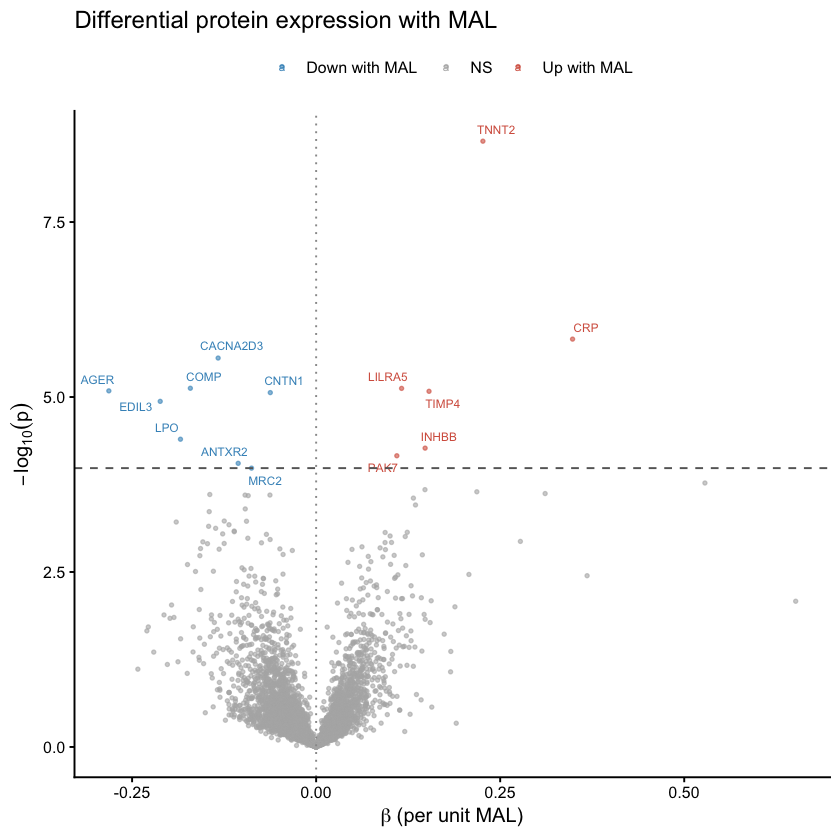

`height` was translated to `width`.
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Top DE proteins — association with emphysema progression' in 'mbcsToSbcs': - substituted for — (U+2014)”
`height` was translated to `width`.
`height` was translated to `width`.


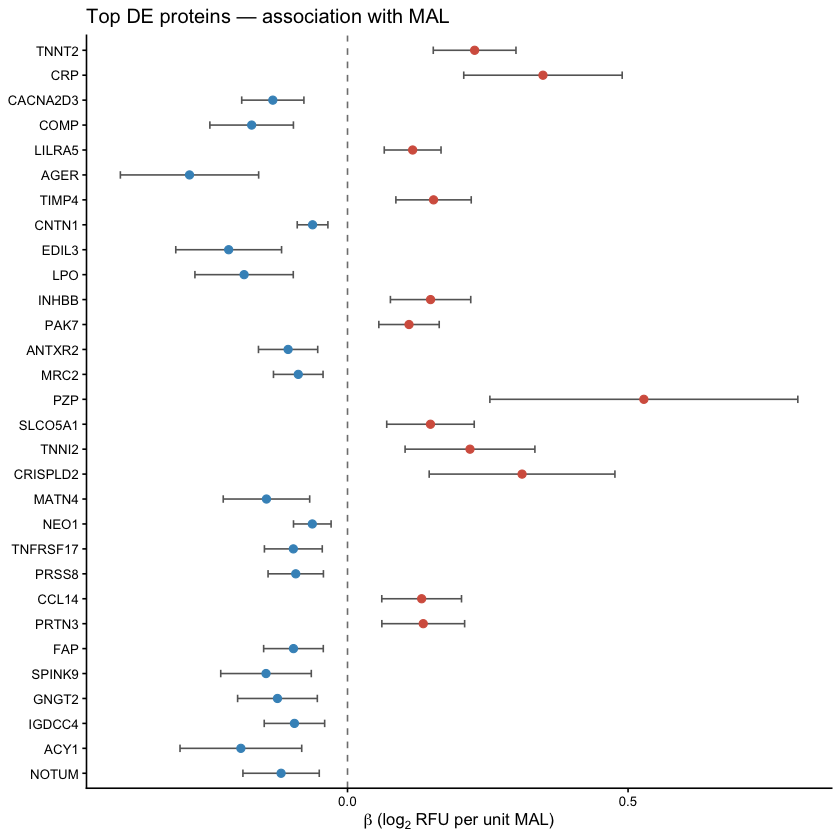

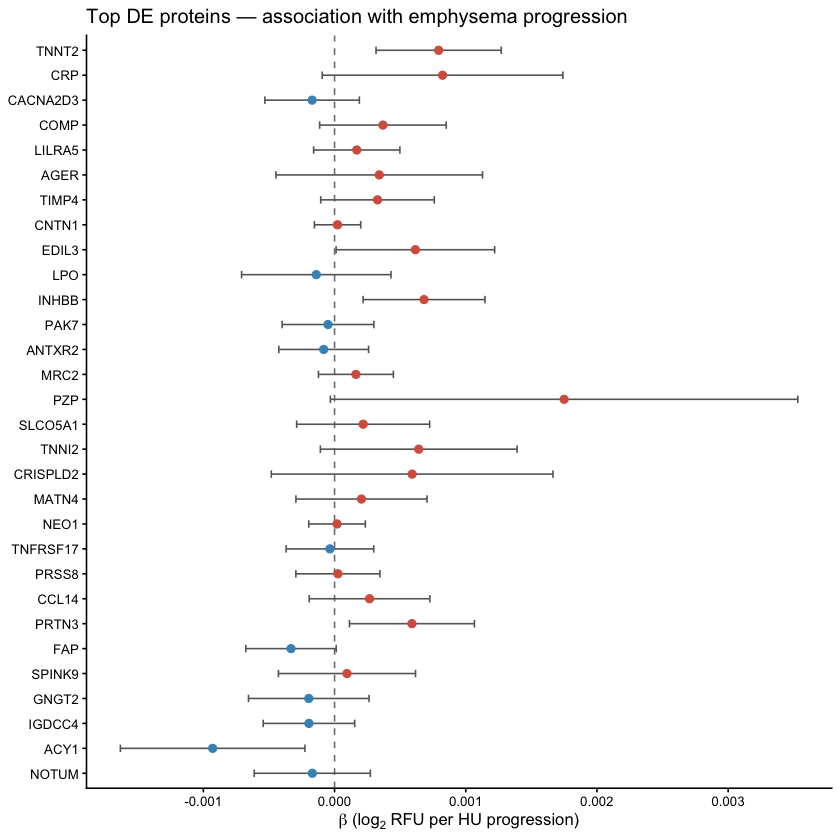

In [8]:
# Figure 2A — Volcano plot: protein ~ MAL
# Colors: Red = up with MAL, Blue = down with MAL, Grey = NS

de_plot <- de_results |>
  mutate(
    significance = case_when(
      FDR < 0.05 & beta > 0 ~ "Up with MAL",
      FDR < 0.05 & beta < 0 ~ "Down with MAL",
      TRUE                  ~ "NS"
    ),
    neg_log10_p = -log10(p_value),
    label = if_else(FDR < 0.05 & rank(FDR) <= 20, gene, NA_character_)
  )

fig2a <- ggplot(de_plot, aes(x = beta, y = neg_log10_p, color = significance)) +
  geom_point(alpha = 0.6, size = 0.8) +
  geom_text_repel(aes(label = label), size = 2.5, max.overlaps = 20, na.rm = TRUE) +
  geom_hline(yintercept = -log10(max(de_results$p_value[de_results$FDR < 0.05],
                                      na.rm = TRUE)),
             linetype = "dashed", color = "grey40") +
  geom_vline(xintercept = 0, linetype = "dotted", color = "grey60") +
  scale_color_manual(values = c("Up with MAL" = "#D6604D",
                                "Down with MAL" = "#4393C3",
                                "NS" = "grey70")) +
  labs(x = expression(beta ~ "(per unit MAL)"),
       y = expression(-log[10](p)),
       color = NULL,
       title = "Differential protein expression with MAL") +
  theme_classic(base_size = 12) +
  theme(legend.position = "top")

ggsave(file.path(FIG_DIR, "Figure2A_volcano.pdf"), fig2a, width=7, height=6)
ggsave(file.path(FIG_DIR, "Figure2A_volcano.png"), fig2a, width=7, height=6, dpi=300)
fig2a

# Supplementary Figures A & B: forest plots for top DE proteins
# Top 30 by |t-statistic| from differential expression
top_de <- de_results |>
  arrange(desc(abs(t_stat))) |>
  slice_head(n = 30) |>
  mutate(
    ci_lower   = beta - 1.96 * se,
    ci_upper   = beta + 1.96 * se,
    gene_label = if_else(is.na(gene) | gene == "",
                         sub("log2_X", "", predictor), gene),
    gene_label = factor(gene_label, levels = rev(gene_label))
  )

# Supp Fig A: DE protein ~ MAL (beta already in de_results)
supp_a <- ggplot(top_de,
                 aes(x = beta, xmin = ci_lower, xmax = ci_upper, y = gene_label)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_errorbarh(height = 0.3, color = "grey40") +
  geom_point(aes(color = beta > 0), size = 2, show.legend = FALSE) +
  scale_color_manual(values = c("TRUE" = "#D6604D", "FALSE" = "#4393C3")) +
  labs(x     = expression(beta ~ "(log"[2] ~ "RFU per unit MAL)"),
       y     = NULL,
       title = "Top DE proteins — association with MAL") +
  theme_classic(base_size = 10)
ggsave(file.path(FIG_DIR, "SuppFig_forest_MAL.pdf"),
       supp_a, width = 8, height = 10)
ggsave(file.path(FIG_DIR, "SuppFig_forest_MAL.png"),
       supp_a, width = 8, height = 10, dpi = 300)
supp_a

# Supp Fig B: same proteins ~ emphysema progression
# Reuses run_protein_lm(); fits lm(protein ~ progression + covariates)
prog_cov_str <- paste(c("lung_density_vnb_P2", cov_vars), collapse = " + ")

prog_lm <- run_protein_lm(
  df                = df_full,
  protein_cols      = top_de$predictor,
  exposure          = "Change_lung_density_vnb_P2_P3",
  covariate_formula = prog_cov_str
)

prog_df <- top_de |>
  left_join(prog_lm |> dplyr::select(predictor, beta_prog = beta, se_prog = se),
            by = "predictor") |>
  mutate(
    ci_prog_lo = beta_prog - 1.96 * se_prog,
    ci_prog_hi = beta_prog + 1.96 * se_prog
  )

supp_b <- ggplot(prog_df,
                 aes(x = beta_prog, xmin = ci_prog_lo, xmax = ci_prog_hi,
                     y = gene_label)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_errorbarh(height = 0.3, color = "grey40") +
  geom_point(aes(color = beta_prog > 0), size = 2, show.legend = FALSE) +
  scale_color_manual(values = c("TRUE" = "#D6604D", "FALSE" = "#4393C3")) +
  labs(x     = expression(beta ~ "(log"[2] ~ "RFU per HU progression)"),
       y     = NULL,
       title = "Top DE proteins — association with emphysema progression") +
  theme_classic(base_size = 10)
ggsave(file.path(FIG_DIR, "SuppFig_forest_progression.pdf"),
       supp_b, width = 8, height = 10)
ggsave(file.path(FIG_DIR, "SuppFig_forest_progression.png"),
       supp_b, width = 8, height = 10, dpi = 300)
supp_b

## Analysis 2 — GSEA

All proteins are ranked by their **t-statistic** for MAL association and tested against
three gene set collections using `fgsea` (Korotkevich et al. 2021):
- **Hallmark (H):** 50 curated biological process signatures
- **KEGG Legacy (C2:CP:KEGG):** metabolic and signaling pathways
- **Reactome (C2:CP:REACTOME):** detailed mechanistic pathways

In [9]:
# Rank vector: t-statistic for MAL, named by gene symbol
# Proteins without gene symbol are excluded (unmappable to pathway databases)
ranks_df <- de_results |>
  filter(!is.na(gene) & gene != "") |>
  group_by(gene) |>
  slice_max(abs(t_stat), n = 1, with_ties = FALSE) |>  # one entry per gene
  ungroup()
ranks <- setNames(ranks_df$t_stat, ranks_df$gene)

# Helper: load gene sets and run fgsea
run_gsea <- function(ranks, collection, subcollection = NULL, source_label) {
  gs <- if (is.null(subcollection)) {
    msigdbr(species = "Homo sapiens", collection = collection)
  } else {
    msigdbr(species = "Homo sapiens", collection = collection,
            subcollection = subcollection)
  }
  pathways <- gs |> group_by(gs_name) |>
    summarise(genes = list(gene_symbol), .groups = "drop") |>
    deframe()

  set.seed(42)
  res <- fgsea(pathways = pathways, stats = ranks,
               minSize = 15, maxSize = 500) |>
    as_tibble() |>
    mutate(source = source_label,
           pathway_clean = gsub("^(HALLMARK|KEGG|REACTOME)_", "", pathway),
           pathway_clean = gsub("_", " ", pathway_clean)) |>
    arrange(padj)
  res
}

message("Running GSEA — Hallmark...")
gsea_hallmark <- run_gsea(ranks, "H", NULL, "Hallmark")
message("Running GSEA — KEGG...")
gsea_kegg     <- run_gsea(ranks, "C2", "CP:KEGG_LEGACY", "KEGG")
message("Running GSEA — Reactome...")
gsea_reactome <- run_gsea(ranks, "C2", "CP:REACTOME", "Reactome")

gsea_all <- bind_rows(gsea_hallmark, gsea_kegg, gsea_reactome)

cat(sprintf("Significant pathways (padj<0.05): Hallmark=%d  KEGG=%d  Reactome=%d\n",
  sum(gsea_hallmark$padj < 0.05, na.rm=TRUE),
  sum(gsea_kegg$padj     < 0.05, na.rm=TRUE),
  sum(gsea_reactome$padj < 0.05, na.rm=TRUE)))

print(gsea_all |> filter(padj < 0.05) |>
  dplyr::select(source, pathway_clean, NES, padj) |> head(20))

Running GSEA — Hallmark...

Running GSEA — KEGG...

Running GSEA — Reactome...



Significant pathways (padj<0.05): Hallmark=1  KEGG=2  Reactome=8
# A tibble: 11 × 4
   source   pathway_clean                                             NES   padj
   <chr>    <chr>                                                   <dbl>  <dbl>
 1 Hallmark FATTY ACID METABOLISM                                   -1.69 0.0388
 2 KEGG     COMPLEMENT AND COAGULATION CASCADES                      1.89 0.0279
 3 KEGG     VALINE LEUCINE AND ISOLEUCINE DEGRADATION               -2.03 0.0279
 4 Reactome ANTIMICROBIAL PEPTIDES                                   2.06 0.0115
 5 Reactome CHEMOKINE RECEPTORS BIND CHEMOKINES                      2.19 0.0115
 6 Reactome DISEASES ASSOCIATED WITH GLYCOSAMINOGLYCAN METABOLISM   -2.07 0.0115
 7 Reactome DISEASES OF METABOLISM                                  -1.87 0.0115
 8 Reactome METABOLISM OF CARBOHYDRATES AND CARBOHYDRATE DERIVATIV… -1.76 0.0188
 9 Reactome BIOLOGICAL OXIDATIONS                                   -1.85 0.0224
10 Reactome KERATAN SULFA

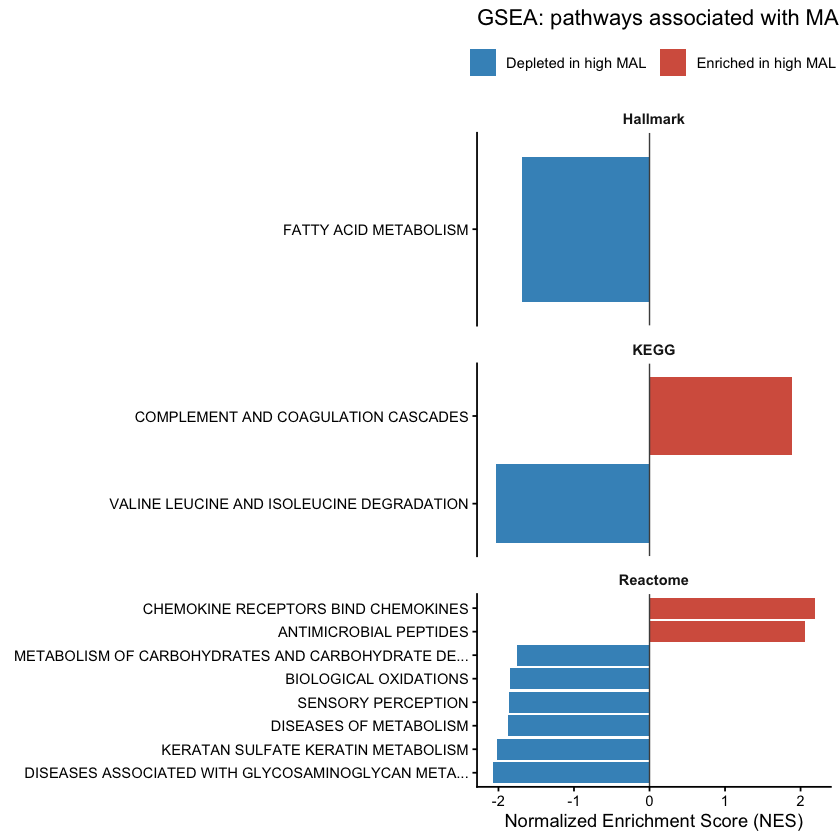

In [10]:
# Figure 2B — GSEA barplot: top significant pathways across all collections

gsea_sig <- gsea_all |>
  filter(padj < 0.05) |>
  group_by(source) |>
  slice_max(abs(NES), n = 10, with_ties = FALSE) |>
  ungroup() |>
  mutate(
    direction     = if_else(NES > 0, "Enriched in high MAL", "Depleted in high MAL"),
    pathway_label = str_trunc(pathway_clean, 50),
    pathway_label = reorder(pathway_label, NES)
  )

fig2b <- ggplot(gsea_sig, aes(x = NES, y = pathway_label, fill = direction)) +
  geom_col() +
  geom_vline(xintercept = 0, color = "grey30", linewidth = 0.4) +
  scale_fill_manual(values = c("Enriched in high MAL" = "#D6604D",
                               "Depleted in high MAL" = "#4393C3")) +
  facet_wrap(~ source, scales = "free_y", ncol = 1) +
  labs(x = "Normalized Enrichment Score (NES)", y = NULL, fill = NULL,
       title = "GSEA: pathways associated with MAL") +
  theme_classic(base_size = 11) +
  theme(legend.position = "top", strip.background = element_blank(),
        strip.text = element_text(face = "bold"))

ggsave(file.path(FIG_DIR, "Figure2B_GSEA.pdf"), fig2b, width=8, height=10)
ggsave(file.path(FIG_DIR, "Figure2B_GSEA.png"), fig2b, width=8, height=10, dpi=300)
fig2b

## Analysis 3 — STRING Protein–Protein Interaction Network

FDR < 0.05 proteins are mapped to the STRING database (v11.5)
to visualise known and predicted protein–protein interactions.
Score threshold = 200 (medium confidence).


Attaching package: ‘igraph’


The following objects are masked from ‘package:purrr’:

    compose, simplify


The following object is masked from ‘package:tidyr’:

    crossing


The following object is masked from ‘package:tibble’:

    as_data_frame


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Mapping 14 significant proteins to STRING...

Mapped: 14 / 14 proteins

Nodes: 14  Edges: 18

Network plot saved.



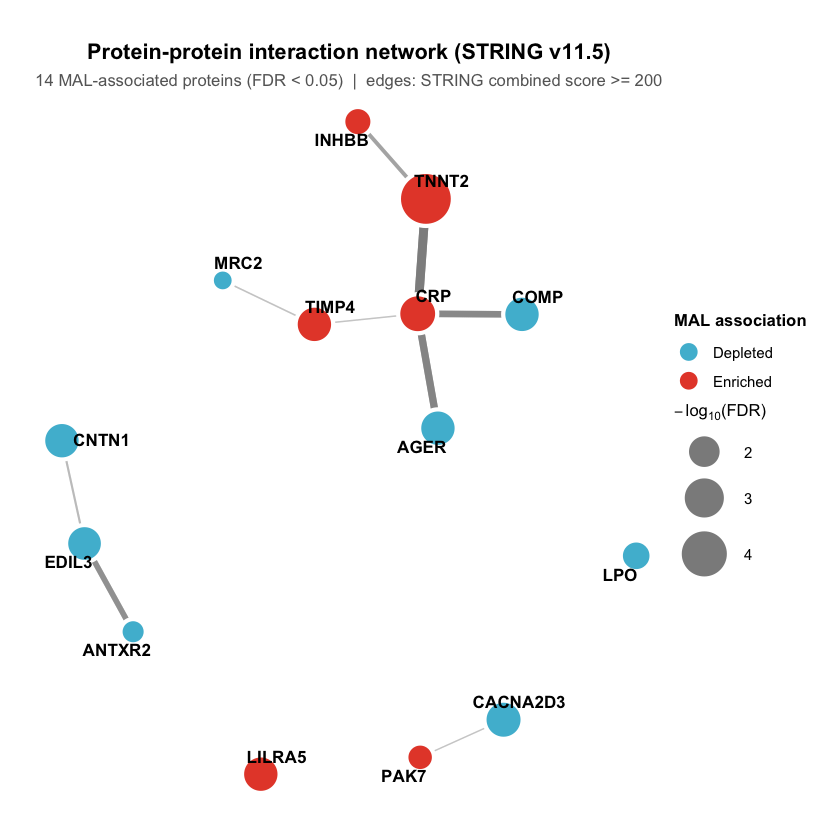

In [11]:
library(igraph)

sig_proteins <- de_results |>
  filter(FDR < 0.05, !is.na(gene), gene != "") |>
  dplyr::select(gene, beta, FDR)

message("Mapping ", nrow(sig_proteins), " significant proteins to STRING...")
string_db <- STRINGdb$new(version = "11.5", species = 9606,
                          score_threshold = 200, input_directory = STRING_DIR)
mapped <- string_db$map(as.data.frame(sig_proteins), "gene", removeUnmappedRows = TRUE)
message("Mapped: ", nrow(mapped), " / ", nrow(sig_proteins), " proteins")

g_raw <- string_db$get_subnetwork(mapped$STRING_id)
message("Nodes: ", vcount(g_raw), "  Edges: ", ecount(g_raw))

node_attrs <- mapped |>
  dplyr::select(name = STRING_id, gene, beta, FDR) |>
  mutate(
    direction = ifelse(beta > 0, "Enriched", "Depleted"),
    log_fdr   = -log10(FDR)
  )
v_df <- data.frame(name = V(g_raw)$name) |>
  left_join(node_attrs, by = "name")
V(g_raw)$gene      <- v_df$gene
V(g_raw)$direction <- v_df$direction
V(g_raw)$log_fdr   <- v_df$log_fdr

set.seed(42)
lay <- layout_with_kk(g_raw)

nodes_df <- data.frame(
  x    = lay[, 1],
  y    = lay[, 2],
  gene = V(g_raw)$gene,
  dir  = V(g_raw)$direction,
  lfdr = V(g_raw)$log_fdr
)

el <- as_edgelist(g_raw, names = FALSE)
if (nrow(el) > 0) {
  edges_df <- data.frame(
    x     = lay[el[, 1], 1], y     = lay[el[, 1], 2],
    xend  = lay[el[, 2], 1], yend  = lay[el[, 2], 2],
    score = E(g_raw)$combined_score
  )
} else {
  edges_df <- data.frame(x=numeric(), y=numeric(),
                         xend=numeric(), yend=numeric(), score=numeric())
}

node_colors <- c("Enriched" = "#E64B35", "Depleted" = "#4DBBD5")

p_network <- ggplot() +
  geom_segment(
    data = edges_df,
    aes(x = x, y = y, xend = xend, yend = yend,
        linewidth = score / 1000, alpha = score / 1000),
    colour = "grey55", show.legend = FALSE
  ) +
  geom_point(
    data = nodes_df,
    aes(x = x, y = y, fill = dir, size = lfdr),
    shape = 21, colour = "white", stroke = 1.8
  ) +
  geom_text_repel(
    data = nodes_df,
    aes(x = x, y = y, label = gene),
    size = 3.6, fontface = "bold",
    point.padding = 0.6, box.padding = 0.4,
    max.overlaps = Inf,
    segment.colour = "grey50", segment.size = 0.35, segment.alpha = 0.7
  ) +
  scale_fill_manual(
    values = node_colors,
    name   = "MAL association"
  ) +
  scale_size_continuous(
    range  = c(5, 14),
    name   = expression(paste(-log[10], "(FDR)")),
    breaks = c(2, 3, 4)
  ) +
  scale_linewidth_continuous(range = c(0.4, 2.5)) +
  scale_alpha_continuous(range = c(0.25, 0.85)) +
  guides(
    fill = guide_legend(
      order = 1,
      override.aes = list(size = 5, shape = 21,
                          colour = "white", stroke = 1.8)
    ),
    size = guide_legend(
      order = 2,
      override.aes = list(shape = 21, fill = "grey55",
                          colour = "white", stroke = 1.8)
    ),
    linewidth = "none",
    alpha     = "none"
  ) +
  theme_void(base_size = 12) +
  theme(
    legend.position  = "right",
    legend.title     = element_text(face = "bold", size = 10),
    legend.text      = element_text(size = 9),
    legend.spacing.y = unit(4, "pt"),
    plot.background  = element_rect(fill = "white", colour = NA),
    plot.title       = element_text(face = "bold", size = 13, hjust = 0.5),
    plot.subtitle    = element_text(size = 10, hjust = 0.5, colour = "grey40"),
    plot.margin      = margin(20, 20, 20, 20)
  ) +
  labs(
    title    = "Protein-protein interaction network (STRING v11.5)",
    subtitle = sprintf(
      "%d MAL-associated proteins (FDR < 0.05)  |  edges: STRING combined score >= 200",
      nrow(mapped)
    )
  )

ggsave(file.path(FIG_DIR, "Figure2C_STRING_network.pdf"), p_network,
       width = 9, height = 7)
ggsave(file.path(FIG_DIR, "Figure2C_STRING_network.png"), p_network,
       width = 9, height = 7, dpi = 200)
message("Network plot saved.")

p_network

## Analysis 3b — STRING MCL Clustering and Cluster Enrichment

MCL (Markov Cluster Algorithm) clustering partitions the STRING interaction network (combined score ≥ 200) into biologically coherent modules (inflation = 2, default). Only clusters with ≥ 3 proteins are retained. For each retained cluster, pathway enrichment is fetched from the STRING API across GO (Process/Function/Component), KEGG, Reactome, UniProt keywords, and PubMed literature co-citation; FDR computed by STRING (Benjamini–Hochberg) against the human proteome background.
Results saved to `STRING_mcl_clusters.csv` and `STRING_cluster_enrichment.csv`.

Running MCL (inflation = 2)...

Cluster sizes (0 = unassigned):




0 1 2 
8 3 3 


Fetching STRING enrichment...

  Cluster 1 (n=3): AGER, COMP, CRP

    -> 3 terms returned

  Cluster 2 (n=3): ANTXR2, CNTN1, EDIL3

    -> 0 terms returned

Saved: STRING_mcl_clusters.csv, STRING_cluster_enrichment.csv




Top 3 enrichment terms per cluster (by FDR):
# A tibble: 3 × 4
# Groups:   cluster [1]
  cluster category description                                               fdr
    <int> <chr>    <chr>                                                   <dbl>
1       1 PMID     (2021) COMP (Cartilage Oligomeric Matrix Protein) Neo… 0.0059
2       1 PMID     (2014) Republished: Value of biomarkers in osteoarthr… 0.0067
3       1 PMID     (2013) Value of biomarkers in osteoarthritis: current… 0.0067


Warning message:
“The `label.size` argument of `geom_label()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `linewidth` argument instead.”
MCL network plot saved.



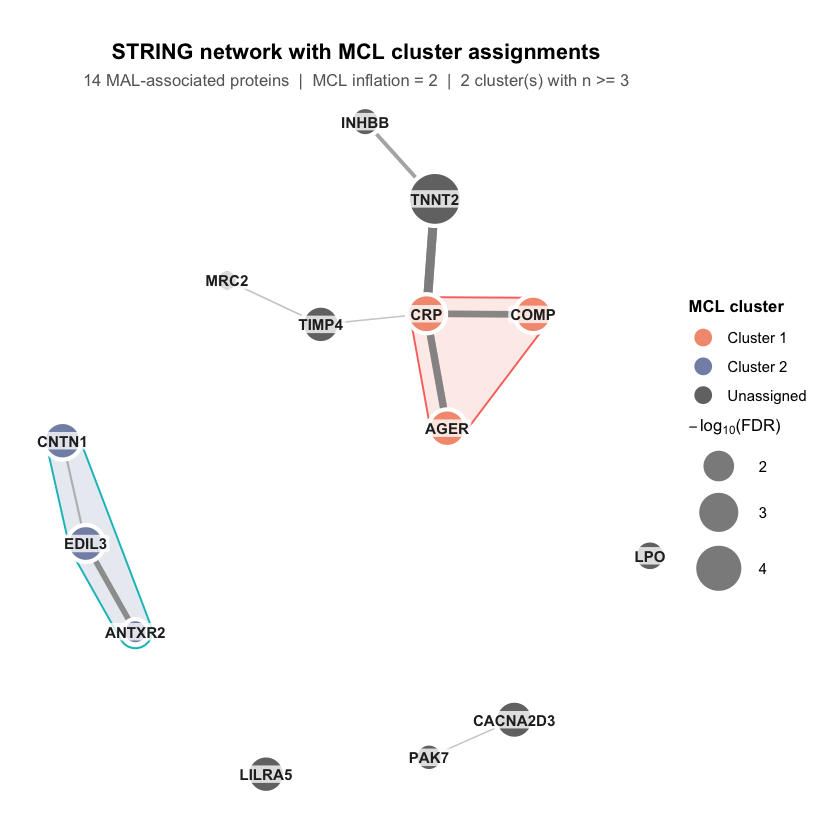

In [13]:
library(MCL)
if (!requireNamespace("ggforce", quietly = TRUE)) install.packages("ggforce")
library(ggforce)

# Reuse g_raw, mapped, nodes_df, edges_df, lay from the STRING network cell
g_simple    <- simplify(g_raw)
vid_to_gene <- setNames(mapped$gene, mapped$STRING_id)
V(g_simple)$name <- vid_to_gene[V(g_simple)$name]

adj <- as_adjacency_matrix(g_simple, sparse = FALSE)

message("Running MCL (inflation = 2)...")
set.seed(42)
mcl_res <- mcl(adj, addLoops = TRUE, inflation = 2)

raw_df <- tibble(
  gene        = rownames(adj),
  string_id   = mapped$STRING_id[match(rownames(adj), mapped$gene)],
  cluster_raw = mcl_res$Cluster
)

cl_sizes <- raw_df |>
  filter(cluster_raw != 0) |>
  count(cluster_raw) |>
  filter(n >= 3) |>
  arrange(desc(n)) |>
  mutate(cluster = seq_len(n()))

cluster_df <- raw_df |>
  left_join(dplyr::select(cl_sizes, cluster_raw, cluster), by = "cluster_raw") |>
  mutate(cluster = ifelse(is.na(cluster), 0L, as.integer(cluster))) |>
  arrange(cluster, gene)

message("Cluster sizes (0 = unassigned):")
print(table(cluster_df$cluster))

# STRING enrichment for each retained cluster
# Return NULL for empty results so bind_rows never sees mismatched column types
message("Fetching STRING enrichment...")
enrich_list <- lapply(seq_len(nrow(cl_sizes)), function(i) {
  ids   <- cluster_df$string_id[cluster_df$cluster == i]
  genes <- cluster_df$gene[cluster_df$cluster == i]
  message("  Cluster ", i, " (n=", length(ids), "): ", paste(genes, collapse = ", "))
  res <- tryCatch(
    string_db$get_enrichment(ids) |> as_tibble(),
    error = function(e) { message("  failed: ", e$message); NULL }
  )
  if (is.null(res) || nrow(res) == 0) {
    message("    -> 0 terms returned"); return(NULL)
  }
  message("    -> ", nrow(res), " terms returned")
  res |> mutate(cluster = i)
})

cluster_enrichment <- bind_rows(Filter(Negate(is.null), enrich_list))

write_csv(cluster_df,         file.path(RES_DIR, "STRING_mcl_clusters.csv"))
write_csv(cluster_enrichment, file.path(RES_DIR, "STRING_cluster_enrichment.csv"))
message("Saved: STRING_mcl_clusters.csv, STRING_cluster_enrichment.csv")

cat("\nTop 3 enrichment terms per cluster (by FDR):\n")
print(
  cluster_enrichment |>
    group_by(cluster) |>
    arrange(fdr) |>
    slice_head(n = 3) |>
    dplyr::select(cluster, category, description, fdr),
  n = 60
)

# ---- Visualization: MCL cluster assignments on same layout ----
n_clusters <- max(cluster_df$cluster)

# Build palette: named vector always includes Unassigned
base_pal    <- c("#F39B7F", "#8491B4", "#91D1C2", "#DC0000")
cl_labels   <- if (n_clusters > 0) paste0("Cluster ", seq_len(n_clusters)) else character(0)
cluster_pal <- setNames(
  c(base_pal[seq_len(n_clusters)], "grey45"),
  c(cl_labels, "Unassigned")
)
all_levels  <- c(cl_labels, "Unassigned")

nodes_mcl <- nodes_df |>
  left_join(dplyr::select(cluster_df, gene, cluster), by = "gene") |>
  mutate(
    cluster = replace_na(cluster, 0L),
    cluster_label = factor(
      ifelse(cluster == 0, "Unassigned", paste0("Cluster ", cluster)),
      levels = all_levels
    )
  )

p_mcl <- ggplot() +
  geom_mark_hull(
    data    = filter(nodes_mcl, cluster_label != "Unassigned"),
    aes(x = x, y = y, fill = cluster_label, colour = cluster_label),
    alpha   = 0.18, expand = unit(10, "pt"), radius = unit(10, "pt"),
    show.legend = FALSE
  ) +
  geom_segment(
    data = edges_df,
    aes(x = x, y = y, xend = xend, yend = yend,
        linewidth = score / 1000, alpha = score / 1000),
    colour = "grey55", show.legend = FALSE
  ) +
  geom_point(
    data = nodes_mcl,
    aes(x = x, y = y, fill = cluster_label, size = lfdr),
    shape = 21, colour = "white", stroke = 1.8
  ) +
  geom_label(
    data = nodes_mcl,
    aes(x = x, y = y, label = gene),
    size = 3.2, fontface = "bold",
    fill = alpha("white", 0.78), colour = "grey15",
    label.size = 0,
    label.padding = unit(0.12, "lines"),
    label.r     = unit(0.10, "lines")
  ) +
  scale_fill_manual(values = cluster_pal, name = "MCL cluster",
                    na.value = "grey45") +
  scale_size_continuous(
    range  = c(5, 14),
    name   = expression(paste(-log[10], "(FDR)")),
    breaks = c(2, 3, 4)
  ) +
  scale_linewidth_continuous(range = c(0.4, 2.5)) +
  scale_alpha_continuous(range = c(0.25, 0.85)) +
  guides(
    fill = guide_legend(
      order = 1,
      override.aes = list(size = 5, shape = 21, colour = "white", stroke = 1.8)
    ),
    size = guide_legend(
      order = 2,
      override.aes = list(shape = 21, fill = "grey55", colour = "white", stroke = 1.8)
    ),
    linewidth = "none",
    alpha     = "none"
  ) +
  theme_void(base_size = 12) +
  theme(
    legend.position  = "right",
    legend.title     = element_text(face = "bold", size = 10),
    legend.text      = element_text(size = 9),
    legend.spacing.y = unit(4, "pt"),
    plot.background  = element_rect(fill = "white", colour = NA),
    plot.title       = element_text(face = "bold", size = 13, hjust = 0.5),
    plot.subtitle    = element_text(size = 10, hjust = 0.5, colour = "grey40"),
    plot.margin      = margin(20, 20, 20, 20)
  ) +
  labs(
    title    = "STRING network with MCL cluster assignments",
    subtitle = sprintf(
      "%d MAL-associated proteins  |  MCL inflation = 2  |  %d cluster(s) with n >= 3",
      nrow(mapped), n_clusters
    )
  )

ggsave(file.path(FIG_DIR, "Figure2C_STRING_MCL.pdf"), p_mcl, width = 9, height = 7)
ggsave(file.path(FIG_DIR, "Figure2C_STRING_MCL.png"), p_mcl, width = 9, height = 7, dpi = 200)
message("MCL network plot saved.")

p_mcl

## Analysis 4 -- MAL Proteomic Risk Score (Adaptive LASSO)

A protein signature of mechanical lung stress is constructed via adaptive LASSO
and summarised as a single scalar score for each participant (`MAL_PRS_scaled`), used for the AIC
model comparison (Analysis 5) and the causal mediation analysis (Analysis 6).

**Outcome:** `meanmal` (CT-derived continuous score, 0.01--0.40)

**Procedure:**
1. 70/30 train/test split (`set.seed(42)`; n_train = 914, n_test = 392)
2. Clinical covariates enter the design matrix as **unpenalised** fixed effects (`penalty.factor = 0`)
3. Residualise `meanmal` on covariates (`lm.fit`) to get `y_resid` for the ridge pre-step only
4. Ridge regression of `y_resid` on proteins only → adaptive weights $w_j = 1/|\hat{\beta}_j^{\text{ridge}}|$
5. Adaptive LASSO ($\alpha = 1$) on raw `meanmal` with adaptive weights, 10-fold CV → $\lambda_{\min}$
6. Post-selection OLS refit on selected proteins → unbiased $\hat{\beta}$, SE, 95\% CI, *p*
7. `MAL_PRS_scaled` = $(\sum_j \hat{\beta}_j \cdot \log_2(\text{protein}_{ij}) - \bar{x}) / s$, standardised across all $n = 1{,}306$ subjects

**Result:** 572 proteins retained; test $R^2 = 0.233$


In [14]:
# 70/30 train/test split — shared by Analysis 4, 5, and 6
set.seed(42)
n_train   <- round(0.70 * nrow(df_full))
train_idx <- sample(nrow(df_full), n_train)
df_train  <- df_full[train_idx, ]
df_test   <- df_full[-train_idx, ]
message("Train: ", nrow(df_train), "  Test: ", nrow(df_test))

# Fixed covariates (unpenalised — known confounders of MAL)
mal_fixed_vars <- c("Age_P2", "gender", "race", "ATS_PackYears_P2",
                    "SmokCigNow_P2", "scanner_model_clean_P2", paste0("PC", 1:5))
if (!is.null(bmi_col)) mal_fixed_vars <- c(mal_fixed_vars, bmi_col)

# Build initial design (uniform weights) for ridge pre-step
d_train_init <- build_design(df_train, protein_cols, mal_fixed_vars)

# Residualise MAL w.r.t. covariates to isolate protein-specific signal
X_cov   <- d_train_init$X[, seq_len(d_train_init$n_fixed), drop = FALSE]
X_prot  <- d_train_init$X[, -seq_len(d_train_init$n_fixed), drop = FALSE]
y_mal   <- df_train$meanmal
y_resid <- residuals(lm.fit(X_cov, y_mal))

# Ridge → adaptive weights
adaptive_weights <- compute_adaptive_weights(X_prot, y_resid)
message("Adaptive weights: min=", round(min(adaptive_weights), 4),
        "  max=", round(max(adaptive_weights), 4))
message("Infinite weights: ", sum(is.infinite(adaptive_weights)))  # must be 0

# Rebuild design matrices with adaptive weights
d_train <- build_design(df_train, protein_cols, mal_fixed_vars, adaptive_weights)
d_test  <- build_design(df_test,  protein_cols, mal_fixed_vars, adaptive_weights,
                        ref_colnames = d_train$colnames)

# Fit adaptive lasso
message("Fitting adaptive lasso for MAL risk score...")
set.seed(42)
lasso_mal <- fit_adaptive_lasso(d_train$X, y_mal, d_train$pf)

# OLS refit on training set
ols_mal <- refit_ols(d_train$X, y_mal, lasso_mal, "lambda.min",
                     protein_cols, d_train$n_fixed)

# Test set R²
y_pred_test <- as.vector(predict(lasso_mal, newx = d_test$X, s = "lambda.min"))
r2_test     <- cor(df_test$meanmal, y_pred_test)^2
message("Test R² for MAL prediction: ", round(r2_test, 3))


Train: 914  Test: 392

Adaptive weights: min=72.3907  max=350217480.1019

Infinite weights: 0

Fitting adaptive lasso for MAL risk score...

Proteins selected: 572

Test R² for MAL prediction: 0.233



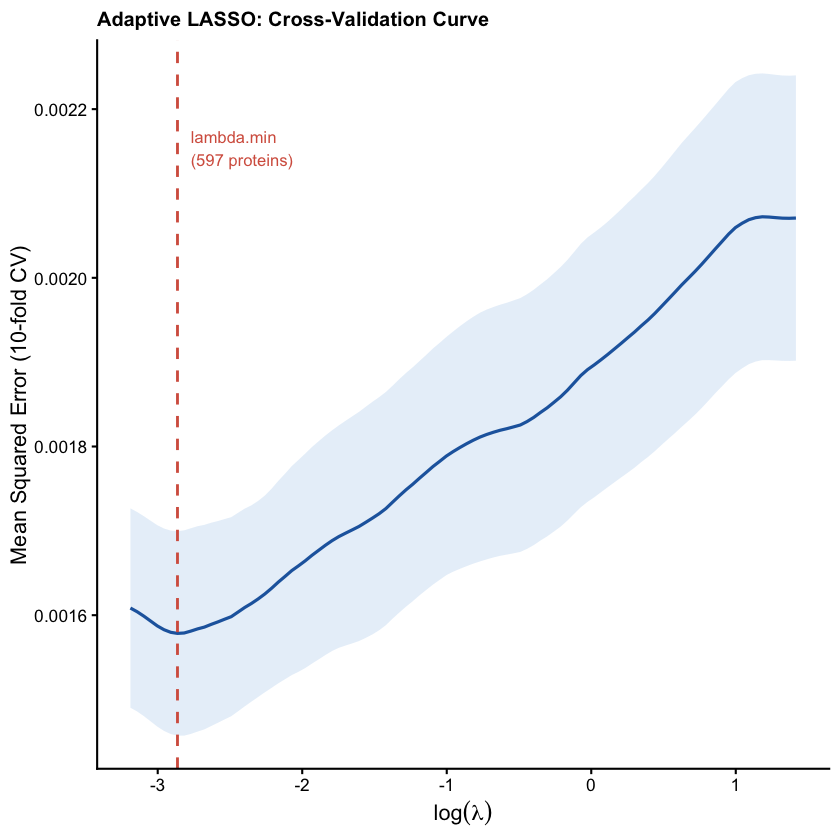

In [15]:
# Supplementary Figure — Adaptive LASSO cross-validation curve
# Shows MSE vs log(lambda); vertical line at lambda.min
# Object `lasso_mal` is the cv.glmnet result from Analysis 4

cv_df <- data.frame(
  log_lambda = log(lasso_mal$lambda),
  cvm        = lasso_mal$cvm,
  cvlo       = lasso_mal$cvlo,
  cvup       = lasso_mal$cvup,
  nzero      = lasso_mal$nzero
)
lmin_log <- log(lasso_mal$lambda.min)

p_cv <- ggplot(cv_df, aes(x = log_lambda, y = cvm)) +
  geom_ribbon(aes(ymin = cvlo, ymax = cvup), fill = "#DEEBF7", alpha = 0.7) +
  geom_line(color = "#2166AC", linewidth = 0.9) +
  geom_vline(xintercept = lmin_log, linetype = "dashed",
             color = "#D6604D", linewidth = 0.8) +
  annotate("text",
           x = lmin_log + diff(range(cv_df$log_lambda)) * 0.02,
           y = max(cv_df$cvup) * 0.97,
           label = sprintf("lambda.min\n(%d proteins)",
                           cv_df$nzero[which.min(abs(cv_df$log_lambda - lmin_log))]),
           hjust = 0, vjust = 1, size = 3.5, color = "#D6604D") +
  labs(
    x     = expression(log(lambda)),
    y     = "Mean Squared Error (10-fold CV)",
    title = "Adaptive LASSO: Cross-Validation Curve"
  ) +
  theme_classic(base_size = 13) +
  theme(plot.title = element_text(face = "bold", size = 12))

ggsave(file.path(FIG_DIR, "SuppFig_CV_curve.pdf"), p_cv, width = 6, height = 4)
ggsave(file.path(FIG_DIR, "SuppFig_CV_curve.png"), p_cv, width = 6, height = 4, dpi = 300)
p_cv

### Compute MAL Proteomic Risk Score (`MAL_PRS_scaled`)

Applies the OLS-refitted coefficients from Analysis 4 to **all $n = 1{,}306$ subjects** (not just the training set) to produce a single blood-based MAL score per participant.

**Steps:**
1. Extract OLS $\hat{\beta}_j$ for the proteins selected by the adaptive LASSO (`ols_mal`)
2. Annotate with gene symbol and target name
3. Compute raw score: $\text{PRS}_i = \sum_j \hat{\beta}_j \cdot \log_2(\text{protein}_{ij})$
4. Standardise across all subjects: $\texttt{MAL\_PRS\_scaled} = (\text{PRS} - \bar{x}) / s$, so mean = 0, SD = 1
5. Assign back to `df_full` for use in Analysis 5 (AIC comparison) and Analysis 6 (mediation)

In [16]:
# -------------------------------------------------------------------
# Compute MAL Proteomic Risk Score (MAL_PRS_scaled) for all subjects
#
# Takes the OLS-refitted coefficients from Analysis 4 (ols_mal) and
# applies them to every subject in df_full (not just the training set)
# to produce a single blood-based MAL score per participant.
#
# Steps:
#   1. Extract OLS betas for the proteins selected by the LASSO
#   2. Annotate with gene symbol and target name (from meta)
#   3. Compute raw PRS = sum_j(beta_j * log2(protein_ij)) over all subjects
#   4. Standardise: subtract mean and divide by SD across all n = 1,306
#      -> MAL_PRS_scaled has mean = 0, SD = 1 for interpretability
#   5. Assign back to df_full for use in Analysis 5 (AIC) and Analysis 6 (mediation)
# -------------------------------------------------------------------

# Step 1-2: pull selected proteins with OLS betas + gene annotation
prot_coefs <- ols_mal |>
  filter(predictor %in% protein_cols) |>
  mutate(abs_beta = abs(beta)) |>
  left_join(meta |> mutate(predictor = paste0("log2_X", seqID)), by = "predictor")

message("Proteins in MAL risk score: ", nrow(prot_coefs))

# Step 3: matrix multiply log2 protein matrix by beta vector -> raw score
selected_prots <- prot_coefs$predictor
betas_vec      <- setNames(prot_coefs$beta, selected_prots)
X_prs          <- as.matrix(df_full[, selected_prots, drop = FALSE])
prs_raw        <- as.vector(X_prs %*% betas_vec)

# Step 4: standardise across all subjects
MAL_PRS_scaled        <- (prs_raw - mean(prs_raw)) / sd(prs_raw)
df_full$MAL_PRS_scaled <- MAL_PRS_scaled

# Step 5: sanity checks — n must equal nrow(df_full), mean ~ 0, sd ~ 1
message("MAL_PRS_scaled n = ", sum(!is.na(MAL_PRS_scaled)),
        "  (expected: ", nrow(df_full), ")")
message("MAL PRS: mean=", round(mean(MAL_PRS_scaled), 3),
        "  sd=",  round(sd(MAL_PRS_scaled), 3),
        "  range [", round(min(MAL_PRS_scaled), 2), ", ", round(max(MAL_PRS_scaled), 2), "]")

# Propagate to df_test so filter(!is.na(MAL_PRS_scaled)) works in Analysis 5
df_test$MAL_PRS_scaled <- df_full$MAL_PRS_scaled[match(df_test$sid, df_full$sid)]

# Show top 20 proteins by absolute beta (strongest contributors to the score)
print(prot_coefs |>
  arrange(desc(abs_beta)) |>
  dplyr::select(gene, target, beta, ci_lower, ci_upper, p_value) |>
  head(20))

Proteins in MAL risk score: 572

MAL_PRS_scaled n = 1306  (expected: 1306)

MAL PRS: mean=0  sd=1  range [-3.34, 5.54]



# A tibble: 20 × 6
   gene     target                  beta ci_lower ci_upper     p_value
   <chr>    <chr>                  <dbl>    <dbl>    <dbl>       <dbl>
 1 SERPINF1 PEDF                   0.216   0.0507   0.381  0.0106     
 2 SERPINA4 Kallistatin           -0.207  -0.331   -0.0827 0.00116    
 3 C7       C7                     0.200   0.0938   0.307  0.000253   
 4 NPS      NPS                    0.182   0.0907   0.273  0.000107   
 5 C3       C3                    -0.180  -0.247   -0.112  0.000000329
 6 MFAP2    MFAP2                  0.178   0.113    0.242  0.000000149
 7 RNASE4   RNAS4                 -0.157  -0.258   -0.0555 0.00250    
 8 CNTN4    Contactin-4            0.150   0.0717   0.229  0.000201   
 9 PGLYRP2  PGRP-L                 0.150   0.0453   0.255  0.00514    
10 SEC13    SEC13                 -0.143  -0.251   -0.0343 0.0100     
11 CNTN1    contactin-1           -0.142  -0.255   -0.0286 0.0142     
12 RGMA     RGMA                   0.139   0.0334   0.244 

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


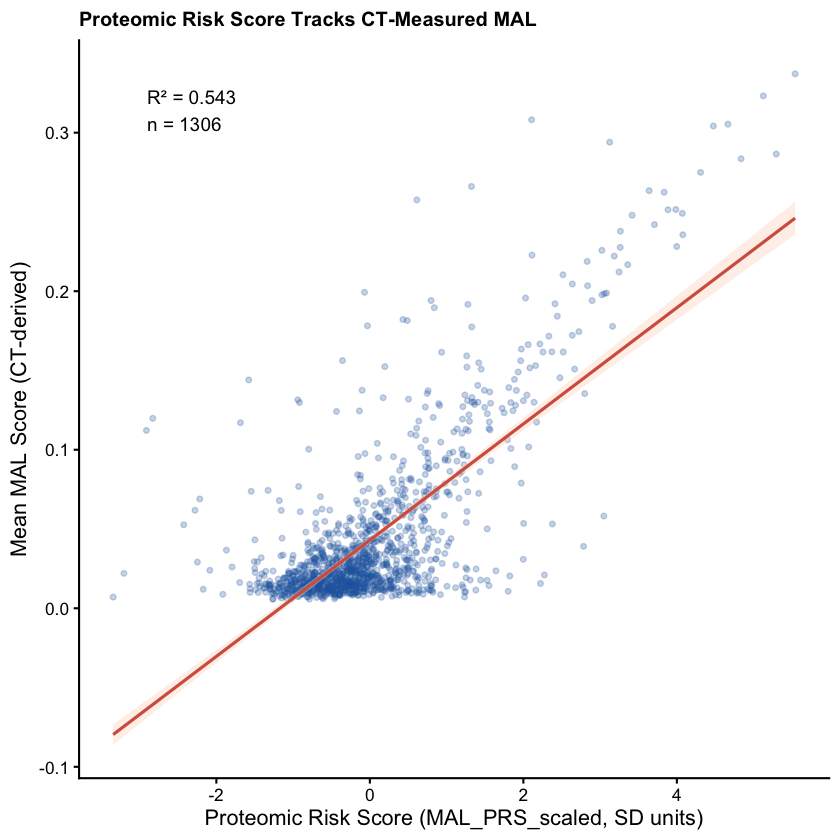

In [17]:
# Supplementary Figure — Proteomic Risk Score vs CT MAL Score
# Validates that MAL_PRS_scaled tracks the CT-derived meanmal

r2_all  <- cor(df_full$MAL_PRS_scaled, df_full$meanmal, use = "complete.obs")^2
r_label <- sprintf("R² = %.3f\nn = %d", r2_all, sum(!is.na(df_full$MAL_PRS_scaled)))

p_scatter <- ggplot(df_full, aes(x = MAL_PRS_scaled, y = meanmal)) +
  geom_point(alpha = 0.25, size = 1.2, color = "#2166AC") +
  geom_smooth(method = "lm", se = TRUE, color = "#D6604D",
              linewidth = 0.9, fill = "#FDDBC7") +
  annotate("text",
           x = min(df_full$MAL_PRS_scaled, na.rm = TRUE) +
               diff(range(df_full$MAL_PRS_scaled, na.rm = TRUE)) * 0.05,
           y = max(df_full$meanmal, na.rm = TRUE) * 0.97,
           label = r_label, hjust = 0, vjust = 1, size = 4) +
  labs(
    x     = "Proteomic Risk Score (MAL_PRS_scaled, SD units)",
    y     = "Mean MAL Score (CT-derived)",
    title = "Proteomic Risk Score Tracks CT-Measured MAL"
  ) +
  theme_classic(base_size = 13) +
  theme(plot.title = element_text(face = "bold", size = 12))

ggsave(file.path(FIG_DIR, "SuppFig_PRS_vs_MAL.pdf"), p_scatter, width = 6, height = 5)
ggsave(file.path(FIG_DIR, "SuppFig_PRS_vs_MAL.png"), p_scatter, width = 6, height = 5, dpi = 300)
p_scatter

## Analysis 5 — Association of MAL Proteomic Risk Score with Emphysema Progression

The MAL PRS (`MAL_PRS_scaled`, standardised across all n = 1,306 subjects) is
evaluated on the held-out 30% test set (n = 392) to test whether the protein
signature of mechanical lung stress independently predicts future emphysema progression
beyond established clinical risk factors.

**Outcome:** `pctprog` (% lung voxels progressing to emphysema, Phase 2→3)

**Models (test set only):**
1. **M1 — Clinical:** age, sex, race, smoking status, pack-years, BMI, scanner (reference)
2. **M2 — MAL PRS + scanner:** `MAL_PRS_scaled` + scanner (scanner as technical confounder)
3. **M3 — Clinical + MAL PRS:** clinical variables + `MAL_PRS_scaled`

Model comparison by AIC ($\Delta \leq -2$ = meaningful improvement). Effect size
$\hat{\beta}$ (95% CI) for `MAL_PRS_scaled` reported from M2 and M3.


In [18]:
# Analysis 5: 3-model comparison on test set, pctprog as outcome, using MAL_PRS_scaled
df_test_cc <- df_test |> filter(!is.na(pctprog), !is.na(MAL_PRS_scaled))
message("Test subjects complete: ", nrow(df_test_cc))

clin_str <- paste(c("Age_P2", "gender", "race", "ATS_PackYears_P2",
                    "SmokCigNow_P2", "scanner_model_clean_P2",
                    if (!is.null(bmi_col)) bmi_col else NULL),
                  collapse = " + ")

m1 <- lm(as.formula(paste("pctprog ~", clin_str)), data = df_test_cc)
m2 <- lm(pctprog ~ MAL_PRS_scaled + scanner_model_clean_P2, data = df_test_cc)
m3 <- lm(as.formula(paste("pctprog ~ MAL_PRS_scaled +", clin_str)), data = df_test_cc)

# AIC comparison
aic_res <- tibble(
  model     = c("Clinical", "MAL PRS + scanner", "Clinical + MAL PRS"),
  AIC       = c(AIC(m1), AIC(m2), AIC(m3)),
  delta_AIC = round(AIC - AIC(m1), 1)
)
cat("AIC comparison (test set, n =", nrow(df_test_cc), "):\n")
print(aic_res)

# Full coefficient tables for all three models
cat("\n--- M1 (Clinical) coefficients ---\n")
print(round(summary(m1)$coefficients, 4))

cat("\n--- M2 (MAL PRS + scanner) coefficients ---\n")
print(round(summary(m2)$coefficients, 4))

cat("\n--- M3 (Clinical + MAL PRS) coefficients ---\n")
print(round(summary(m3)$coefficients, 4))

# Effect sizes for MAL PRS (key summary)
cat("\nMAL PRS effect sizes (key result):\n")
for (info in list(list("M2 (MAL PRS + scanner)", m2), list("M3 (Clinical + MAL PRS)", m3))) {
  nm  <- info[[1]]; mod <- info[[2]]
  ci  <- confint(mod)["MAL_PRS_scaled", ]
  cs  <- summary(mod)$coefficients["MAL_PRS_scaled", ]
  cat(sprintf("  %s:  beta = %.3f%%  95%% CI [%.3f, %.3f]  p = %.3e\n",
              nm, cs["Estimate"], ci[1], ci[2], cs["Pr(>|t|)"]))
}

write_csv(aic_res, file.path(RES_DIR, "aic_comparison.csv"))

Test subjects complete: 392



AIC comparison (test set, n = 392 ):
# A tibble: 3 × 3
  model                AIC delta_AIC
  <chr>              <dbl>     <dbl>
1 Clinical           2259.       0  
2 MAL PRS + scanner  2287.      27.4
3 Clinical + MAL PRS 2246.     -13.5

--- M1 (Clinical) coefficients ---
                                       Estimate Std. Error t value Pr(>|t|)
(Intercept)                             10.0748     3.0987  3.2513   0.0013
Age_P2                                   0.0954     0.0329  2.8955   0.0040
gender                                  -1.2173     0.4478 -2.7182   0.0069
race                                    -0.3255     0.5935 -0.5485   0.5837
ATS_PackYears_P2                         0.0318     0.0097  3.2813   0.0011
SmokCigNow_P2                           -1.3111     0.5277 -2.4845   0.0134
scanner_model_clean_P2Definition        -4.6042     1.5517 -2.9672   0.0032
scanner_model_clean_P2DefinitionAS      -7.5957     1.6228 -4.6807   0.0000
scanner_model_clean_P2DefinitionAS+     

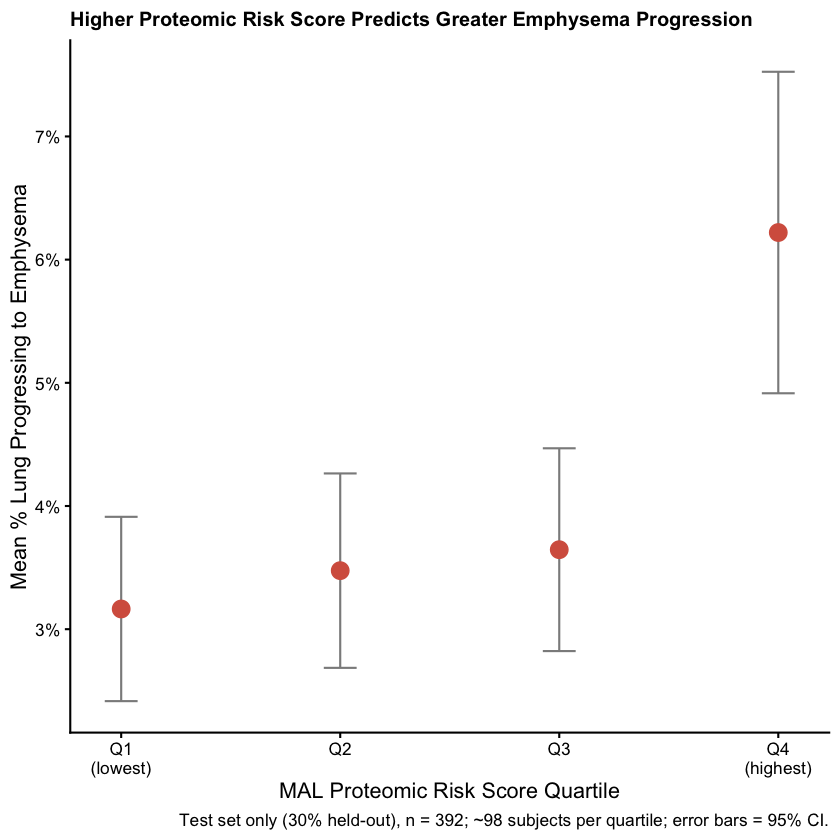

In [19]:
# Figure: Higher MAL Proteomic Risk Score quartile -> higher emphysema progression
# Evaluated on held-out test set (30%) to avoid data leakage
dec_df <- df_test_cc |>
  mutate(quartile = ntile(MAL_PRS_scaled, 4)) |>
  group_by(quartile) |>
  summarise(
    mean_prog = mean(pctprog, na.rm = TRUE),
    se_prog   = sd(pctprog,   na.rm = TRUE) / sqrt(n()),
    n         = n(),
    .groups   = "drop"
  ) |>
  mutate(ci_lo = mean_prog - 1.96 * se_prog,
         ci_hi = mean_prog + 1.96 * se_prog)

p_prs_decile <- ggplot(dec_df, aes(x = quartile, y = mean_prog)) +
  geom_errorbar(aes(ymin = ci_lo, ymax = ci_hi),
                width = 0.15, colour = "grey55", linewidth = 0.6) +
  geom_point(size = 4.5, colour = "#D6604D") +
  scale_x_continuous(breaks = 1:4, labels = c("Q1\n(lowest)", "Q2", "Q3", "Q4\n(highest)")) +
  scale_y_continuous(labels = function(y) paste0(y, "%")) +
  labs(
    x       = "MAL Proteomic Risk Score Quartile",
    y       = "Mean % Lung Progressing to Emphysema",
    title   = "Higher Proteomic Risk Score Predicts Greater Emphysema Progression",
    caption = sprintf("Test set only (30%% held-out), n = %d; ~%d subjects per quartile; error bars = 95%% CI.",
                      nrow(df_test_cc), round(nrow(df_test_cc) / 4))
  ) +
  theme_classic(base_size = 13) +
  theme(plot.title = element_text(face = "bold", size = 12))

ggsave(file.path(FIG_DIR, "Figure_PRS_decile.pdf"), p_prs_decile, width = 7, height = 5)
ggsave(file.path(FIG_DIR, "Figure_PRS_decile.png"), p_prs_decile, width = 7, height = 5, dpi = 300)
p_prs_decile

MAL_PRS_scaled: D10/D1 = 3.1x  p = 1.52e-40


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


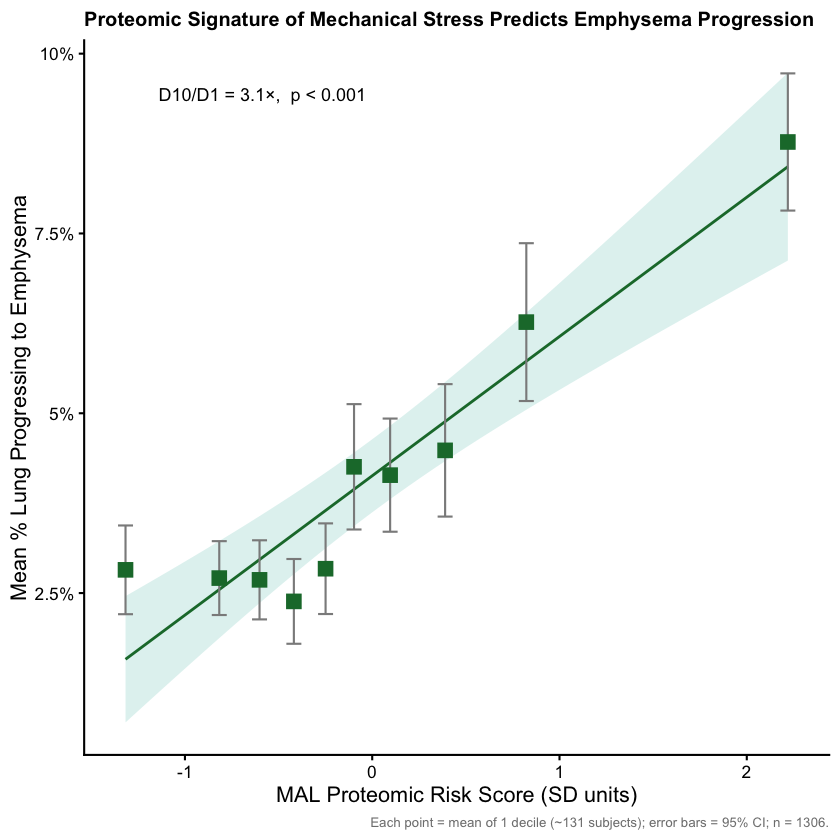

In [20]:
# Figure 3: Proteomic Risk Score vs Emphysema Progression (decile dot plot)
# x = mean MAL_PRS_scaled within each decile bin
# y = mean pctprog within each decile bin

sum_prs <- df_full |>
  filter(!is.na(MAL_PRS_scaled), !is.na(pctprog)) |>
  mutate(decile = ntile(MAL_PRS_scaled, 10)) |>
  group_by(decile) |>
  summarise(
    mean_prs  = mean(MAL_PRS_scaled, na.rm = TRUE),
    mean_prog = mean(pctprog,        na.rm = TRUE),
    se_prog   = sd(pctprog,          na.rm = TRUE) / sqrt(n()),
    n         = n(),
    .groups   = "drop"
  ) |>
  mutate(
    ci_lo = mean_prog - 1.96 * se_prog,
    ci_hi = mean_prog + 1.96 * se_prog
  )

d10d1_prs <- sum_prs$mean_prog[10] / sum_prs$mean_prog[1]
p_prs     <- summary(lm(pctprog ~ MAL_PRS_scaled,
                         data = df_full |> filter(!is.na(pctprog))))$coefficients[2, 4]
cat(sprintf("MAL_PRS_scaled: D10/D1 = %.1fx  p = %.2e\n", d10d1_prs, p_prs))

fig3 <- ggplot(sum_prs, aes(x = mean_prs, y = mean_prog,
                             ymin = ci_lo, ymax = ci_hi)) +
  geom_smooth(method = "lm", se = TRUE, color = "#1B7837",
              fill = "#b2dfdb", linewidth = 0.8) +
  geom_errorbar(width = 0.08, linewidth = 0.6, color = "grey55") +
  geom_point(size = 4, color = "#1B7837", shape = 15) +
  scale_y_continuous(labels = function(y) paste0(y, "%")) +
  annotate("text",
           x    = min(sum_prs$mean_prs) + 0.05 * diff(range(sum_prs$mean_prs)),
           y    = max(sum_prs$ci_hi) * 0.98,
           hjust = 0, vjust = 1, size = 3.8,
           label = sprintf("D10/D1 = %.1f×,  p < 0.001", d10d1_prs)) +
  labs(
    x       = "MAL Proteomic Risk Score (SD units)",
    y       = "Mean % Lung Progressing to Emphysema",
    title   = "Proteomic Signature of Mechanical Stress Predicts Emphysema Progression",
    caption = sprintf(
      "Each point = mean of 1 decile (~%d subjects); error bars = 95%% CI; n = %d.",
      round(sum(sum_prs$n) / 10), sum(sum_prs$n))
  ) +
  theme_classic(base_size = 13) +
  theme(
    plot.title   = element_text(face = "bold", size = 12),
    plot.caption = element_text(size = 8, color = "grey50")
  )

ggsave(file.path(FIG_DIR, "Figure3_quartile_plot.pdf"), fig3, width = 7, height = 5)
ggsave(file.path(FIG_DIR, "Figure3_quartile_plot.png"), fig3, width = 7, height = 5, dpi = 300)
fig3

## Analysis 6 — Causal Mediation (medflex)

**Model:** MAL → MAL Proteomic Risk Score → Emphysema Progression

Using the natural effects framework (`medflex`; Vansteelandt & Lange 2012):
- **NDE** (Natural Direct Effect): effect of MAL on progression NOT through proteins
- **NIE** (Natural Indirect Effect): effect of MAL on progression THROUGH proteins
- **Total effect** = NDE + NIE
- **Proportion mediated** = NIE / Total

**Supplement:** same mediation for each individual protein in the risk score.

In [21]:
# Ensure factor variables are properly coded before medflex
df_med <- df_full |>
  mutate(
    gender                = factor(gender),
    race                  = factor(race),
    SmokCigNow_P2         = factor(SmokCigNow_P2),
    scanner_model_clean_P2 = factor(scanner_model_clean_P2)
  )

med_covs <- paste(c("lung_density_vnb_P2", "Age_P2", "gender", "race",
                    "ATS_PackYears_P2", "SmokCigNow_P2", "scanner_model_clean_P2",
                    if (!is.null(bmi_col)) bmi_col else NULL),
                  collapse = " + ")

message("Fitting natural effect model (medflex)...")
set.seed(42)
imp_data <- neImpute(
  as.formula(paste(
    "Change_lung_density_vnb_P2_P3 ~ meanmal * MAL_PRS_scaled +", med_covs
  )),
  family = gaussian(link = "identity"),
  data   = df_med
)

ne_mod <- neModel(
  as.formula(paste(
    "Change_lung_density_vnb_P2_P3 ~ meanmal0 + meanmal1 +", med_covs
  )),
  family  = gaussian(link = "identity"),
  expData = imp_data,
  se      = "robust"
)

print(summary(ne_mod))

# Extract NDE, NIE, total effect, proportion mediated
ne_coefs   <- summary(ne_mod)$coefficients
nde        <- ne_coefs["meanmal0", "Estimate"]
nie        <- ne_coefs["meanmal1", "Estimate"]
total_eff  <- nde + nie
prop_med   <- nie / total_eff

cat(sprintf("\nNDE  = %.4f  (direct effect of MAL not through proteins)\n", nde))
cat(sprintf("NIE  = %.4f  (indirect effect of MAL through proteins)\n", nie))
cat(sprintf("Total = %.4f\n", total_eff))
cat(sprintf("Proportion mediated = %.1f%%\n", 100 * prop_med))

Fitting natural effect model (medflex)...



Natural effect model
with robust standard errors based on the sandwich estimator
---
Exposure: meanmal 
Mediator(s): MAL_PRS_scaled 
---
Parameter estimates:
                                         Estimate Std. Error z value Pr(>|z|)
(Intercept)                             -8.209382   2.775521  -2.958 0.003099
meanmal0                                -0.547866   7.351967  -0.075 0.940597
meanmal1                                13.932042   4.422616   3.150 0.001632
lung_density_vnb_P2                      0.015623   0.016551   0.944 0.345229
Age_P2                                   0.061236   0.027642   2.215 0.026739
gender2                                  1.246667   0.425722   2.928 0.003408
race2                                   -0.841142   0.590198  -1.425 0.154103
ATS_PackYears_P2                         0.012759   0.009519   1.340 0.180105
SmokCigNow_P21                           2.998798   0.531181   5.646 1.65e-08
scanner_model_clean_P2Definition        -0.985331   1.610141  

In [22]:
# Supplement: mediation for individual proteins in the risk score
# Run only for proteins with p < 0.05 in OLS refit to limit computation
supp_proteins <- prot_coefs |> filter(p_value < 0.05) |> pull(predictor)
message("Running individual mediation for ", length(supp_proteins), " proteins...")

med_raw <- map_dfr(supp_proteins, function(prot) {
  tryCatch({
    df_med[["mediator"]] <- df_med[[prot]]
    imp <- neImpute(
      as.formula(paste("Change_lung_density_vnb_P2_P3 ~ meanmal * mediator +", med_covs)),
      family = gaussian(), data = df_med
    )
    mod <- neModel(
      as.formula(paste("Change_lung_density_vnb_P2_P3 ~ meanmal0 + meanmal1 +", med_covs)),
      family = gaussian(), expData = imp, se = "robust"
    )
    coefs <- summary(mod)$coefficients
    tibble(
      predictor = prot,
      NDE       = coefs["meanmal0", "Estimate"],
      NDE_p     = coefs["meanmal0", "Pr(>|z|)"],
      NIE       = coefs["meanmal1", "Estimate"],
      NIE_p     = coefs["meanmal1", "Pr(>|z|)"],
      prop_med  = coefs["meanmal1", "Estimate"] /
                    (coefs["meanmal0", "Estimate"] + coefs["meanmal1", "Estimate"])
    )
  }, error = function(e) NULL)
})

if (nrow(med_raw) > 0 && "predictor" %in% names(med_raw)) {
  mediation_supp <- med_raw |>
    left_join(meta |> mutate(predictor = paste0("log2_X", seqID)), by = "predictor") |>
    arrange(NIE_p)
  message("Converged: ", nrow(mediation_supp), " of ", length(supp_proteins), " proteins")
  print(mediation_supp |> dplyr::select(gene, target, NDE, NIE, prop_med, NIE_p) |> head(20))
} else {
  message("No proteins converged in individual mediation (", length(supp_proteins), " attempted).")
  mediation_supp <- tibble()
}

Running individual mediation for 205 proteins...

Converged: 202 of 205 proteins



# A tibble: 20 × 6
   gene     target                  NDE    NIE prop_med  NIE_p
   <chr>    <chr>                 <dbl>  <dbl>    <dbl>  <dbl>
 1 TREM2    TREM2                  13.7  2.78    0.169  0.0119
 2 MANSC4   MANS4                  14.2  1.73    0.109  0.0120
 3 EPHB2    EPHB2                  20.5 -1.64   -0.0865 0.0161
 4 DEFA5    HD-5                   14.6  1.66    0.102  0.0170
 5 ADH7     ADH7                   15.0  1.79    0.107  0.0208
 6 ADAMTS5  ADAMTS-5               15.4  1.22    0.0735 0.0210
 7 INHBB    Inhibin bB chain       13.1  2.88    0.180  0.0223
 8 SCG3     SCG3                   13.5  2.65    0.164  0.0291
 9 MSMP     PSMP                   13.8  1.78    0.114  0.0339
10 PDCD1    PD-1                   16.3  0.762   0.0448 0.0483
11 NPTXR    NPTXR                  14.6  1.94    0.117  0.0520
12 GSR      Glutathione reductase  19.5 -1.74   -0.0978 0.0538
13 TRAPPC5  TPPC5                  15.2  1.41    0.0849 0.0572
14 ERN1     ERN1                   1

## Save Outputs

| File | Contents |
|------|----------|
| `mal_de_results.csv` | All protein ~ MAL associations (β, SE, t, p, FDR, gene) |
| `mal_gsea_results.csv` | GSEA results across Hallmark, KEGG, Reactome |
| `mal_risk_score_weights.csv` | Selected proteins + OLS β, SE, CI, p |
| `mal_risk_score_subjects.csv` | Per-subject MAL_PRS_scaled + outcome + split |
| `mal_mediation_results.csv` | medflex NDE/NIE/proportion mediated (full score) |
| `mal_mediation_supp.csv` | Individual protein mediation results |

In [23]:
write_csv(de_results |> dplyr::select(gene, target, full_name, beta, se, t_stat, p_value, FDR),
          file.path(RES_DIR, "mal_de_results.csv"))
message("Saved: mal_de_results.csv")

write_csv(gsea_all |> dplyr::select(source, pathway, pathway_clean, NES, padj, size),
          file.path(RES_DIR, "mal_gsea_results.csv"))
message("Saved: mal_gsea_results.csv")

write_csv(prot_coefs |> dplyr::select(gene, target, beta, se, ci_lower, ci_upper, p_value),
          file.path(RES_DIR, "mal_risk_score_weights.csv"))
message("Saved: mal_risk_score_weights.csv")

prs_subject_df <- tibble(
  sid            = df_full$sid,
  MAL_PRS_scaled = df_full$MAL_PRS_scaled,
  meanmal        = df_full$meanmal,
  Change_lung_density_vnb_P2_P3 = df_full$Change_lung_density_vnb_P2_P3,
  split = case_when(
    df_full$sid %in% df_train$sid ~ "train",
    TRUE                          ~ "test"
  )
)
write_csv(prs_subject_df, file.path(RES_DIR, "mal_risk_score_subjects.csv"))
message("Saved: mal_risk_score_subjects.csv")

# Mediation results (full risk score)
ne_coefs_df <- as_tibble(summary(ne_mod)$coefficients, rownames = "term") |>
  mutate(effect = recode(term,
    meanmal0 = "NDE (direct)",
    meanmal1 = "NIE (indirect via proteins)"
  ))
write_csv(ne_coefs_df, file.path(RES_DIR, "mal_mediation_results.csv"))
message("Saved: mal_mediation_results.csv")

if (nrow(mediation_supp) > 0) {
  write_csv(mediation_supp |> dplyr::select(gene, target, NDE, NDE_p, NIE, NIE_p, prop_med),
            file.path(RES_DIR, "mal_mediation_supp.csv"))
  message("Saved: mal_mediation_supp.csv")
}

message("=== Analysis complete ===")

Saved: mal_de_results.csv

Saved: mal_gsea_results.csv

Saved: mal_risk_score_weights.csv

Saved: mal_risk_score_subjects.csv

Saved: mal_mediation_results.csv

Saved: mal_mediation_supp.csv

=== Analysis complete ===

